# Pricing vanilla call options and computing implied volatilities using neural networks



In [1]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Updating scipy to use module QMC for Latin hypercube sampling
#!pip install scipy==1.7
from scipy.stats import qmc

# Pytorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR, LinearLR, OneCycleLR, LambdaLR

class BS_ANN(nn.Module):
  def __init__(self):
    """
    Initilize BS-ANN netwwork with four hidden layers. 
    Same architecture as the one used in table 2.
    Weight are initialized using Glorot_uniform also known as Xavier_uniform.
    """
    super(BS_ANN, self).__init__()
    # 4 layers
    self.fc1 = nn.Linear(4, 400)
    self.fc2 = nn.Linear(400, 400)
    self.fc3 = nn.Linear(400, 400)
    self.fc4 = nn.Linear(400, 400)
    self.fc5 = nn.Linear(400, 1)
    # initilizing the layer's weights
    torch.nn.init.xavier_uniform_(self.fc1.weight)
    torch.nn.init.xavier_uniform_(self.fc2.weight)
    torch.nn.init.xavier_uniform_(self.fc3.weight)
    torch.nn.init.xavier_uniform_(self.fc4.weight)
    torch.nn.init.xavier_uniform_(self.fc5.weight)


  def forward(self, x):
    """
    Foward pass of the network. 
    Relu activations are used and a linear activation is used in the final layer.
    x: input torch tensor (CUDA or CPU)
    """
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = F.relu(self.fc4(x))
    x = self.fc5(x)
    return x.flatten()

  def train_model(self, args, device, train_loader, optimizer, epoch):
    """
    Training over train_loader batches for one epoch.
    Returns average training loss.
    args: training parameters.
    device: CUDA or CPU.
    train_loader: train data loader.
    optimizer: gradient descent optmizer.
    epoch: current epoch.
    """
    # train mode
    self.train()
    train_loss = 0
    # loop over data loader
    for batch_idx, data in enumerate(train_loader):
      # extracting the inputs and target
      data, target = data[:,:-1].to(device), data[:,-1].to(device)
      # zeroing the gradients
      optimizer.zero_grad()
      # foward pass
      output = self(data)
      # computing the loss
      loss = F.mse_loss(output, target)
      train_loss += loss.item() * data.shape[0]
      # back propagation
      loss.backward()
      # updating the optimizer step
      optimizer.step()
      # printing batch information
      if batch_idx % args["log_interval"] == 0:
        print('Train Epoch: {} [{}/{} ({:.0f}%)]\tlog Loss: {:.6f}'.format(
            epoch, int(batch_idx / len(train_loader)*len(train_loader.dataset)), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), np.log(loss.item())))
        if args["dry_run"]:
          break
    train_loss /= len(train_loader.dataset)
    print('\nTrain set: Average log loss: {:.4f}\n'.format(np.log(train_loss))) 
    return train_loss


  def test_model(self, device, test_loader):
    """
    Testing over test_loader batches for one epoch. 
    Returns average test loss.
    device: CUDA or CPU.
    test_loader: test data loader.
    """
    # evaluation mode
    self.eval()
    test_loss = 0
    # freezing the gradients
    with torch.no_grad():
      # looping over the test laoder
      for data in test_loader:
        # extracting the inputs and target
        data, target = data[:,:-1].to(device), data[:,-1].to(device)
        # foward pass
        output = self(data)
        #computing the loss
        test_loss += F.mse_loss(output, target, reduction = 'sum').item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}\n'.format(np.log(test_loss))) 
    return test_loss
  
  



In [14]:
def call_cosine_coef_moy(a, b, c, d, N):
  k = np.arange(N).reshape(1,-1)
  bma    = b - a
  uu     = k * np.pi / bma
  chi_k = 1 / (1 + uu **2 ) * \
  ( np.cos(uu * ( d - a))* np.exp(d) - np.cos(uu * (c - a))* np.exp(c) + uu * np.sin(uu * (d - a)) * np.exp(d)- uu * np.sin(uu*(c-a))* np.exp(c) )
  psi_k = uu
  psi_k[:,1:] = 1 / uu[:,1:] * ( np.sin(uu[:,1:] * ( d - a )) - np.sin( uu[:,1:] * ( c - a) ) )
  psi_k[:,0] = (d - c).flatten() #d - c 
  return 2/bma*(chi_k-psi_k)

def phi_Heston(a ,b ,N ,r, tau, kappa, gamma, vbar, v0, rho):
  k = np.arange(N).reshape(1,-1)
  u = np.pi*k/(b-a)
  i = complex(0.0,1.0)
  D = np.sqrt((kappa-gamma*rho*i*u)**2+(u**2+i*u)*gamma**2)
  G = (kappa-gamma*rho*i*u-D)/(kappa-gamma*rho*i*u+D)
  C = v0* (1-np.exp(-D*tau)) / (gamma**2*(1-G*np.exp(-D*tau)))*(kappa-gamma*rho*i*u-D)
  A = r*i*u*tau + kappa*vbar/(gamma**2)*(tau*(kappa-gamma*rho*i*u-D) -2*np.log( (1-G*np.exp(-D*tau))/(1-G) )   ) 
  phi = np.exp( A + C )
  return phi

def Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho ):
  c1 = r * tau + (1 - np.exp(- kappa * tau)) * (vbar - v0) / (2 * kappa) - 0.5 * vbar * tau
  
  c2 = 0.125 / kappa ** 3 * (gamma * tau * np.exp(- kappa * tau) * (v0 - vbar) * (8 * kappa * rho - 4 * gamma) + \
     kappa * rho * gamma * (1 - np.exp(- kappa * tau)) * (16 * vbar - 8 * v0) + \
     2 * vbar * kappa * tau * (- 4 * kappa * rho * gamma + gamma ** 2 + 4 * kappa ** 2) + \
     gamma ** 2 * ((vbar - 2 * v0) * np.exp(-2 * kappa * tau) + vbar * (6 * np.exp(- kappa * tau) - 7) + 2 * v0) + \
     8 * kappa ** 2 * (v0 - vbar) * (1 - np.exp(-kappa * tau)))
  return c1, c2

def Truncation_range(c1, c2, c4, L):
  a = c1 - L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) )
  b = c1 + L * np.sqrt( np.abs( c2 ) + np.sqrt( np.abs(c4) ) ) 
  return a, b

def exponential_coef_moy(a, b, N, moyeness):
  i = complex(0.0,1.0)
  k = np.arange(N).reshape(1,-1)
  return np.exp(i*k*np.pi*(np.log(moyeness)-a)/(b-a))

def call_option_Heston_moy(N, L, r, tau, kappa, gamma, vbar, v0, rho, moyeness ):
  c1, c2 = Heston_cumulants( r, tau, kappa, gamma, vbar, v0, rho )
  c4 = 0
  a, b = Truncation_range(c1, c2, c4, L)
  c= 0
  d = b
  V_k = call_cosine_coef_moy(a, b, c, d, N)
  phi_k = phi_Heston(a, b, N, r, tau, kappa, gamma, vbar, v0, rho)
  product_k = V_k * phi_k * exponential_coef_moy(a, b, N, moyeness)
  product_k[:,0] = .5 * product_k[:,0]
  return np.exp(-r*tau)*(np.real(  np.sum( product_k,1 )  )).reshape(-1,1)

In [15]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(device)

cuda


In [16]:
def bs_price_call(S, K, T, t, r, sigma):
  """
  Black-Scholes call option value price related to PDE (2). Returns option's price.
  S: spot price
  K: strike price
  T: time to maturity
  t: spot time
  r: interest rate
  sigma: volatility of underlying asset
  """

  # Boundary condition of Black-Sholes PDE (2)
  if T == t:
    return np.maximum(0, S - K)  
  # Solution of the PDE (2) on the open interval [t, T)
  else : 
    d1 = ( np.log(S / K) + (r + 0.5 * sigma ** 2) * (T-t) ) / (sigma * np.sqrt(T-t))
    d2 = d1 - sigma*np.sqrt(T-t)
    value = S * norm.cdf(d1) - K * np.exp(-r * (T-t)) * norm.cdf(d2) 
  
  return value

def bs_moneyness_call(moneyness, tau, r, sigma):
  """
  Same function as bs_price_call but in terms of moneyness. Returns V/K and 
  has S/K instead of two seperate paremeters S and K.
  moneyness: S/K
  Tau: time to maturity minus spot time
  r: interest rate
  sigma: volatility of underlying asset
  """

  d1 = ( np.log(moneyness) + (r + 0.5 * sigma ** 2) * (tau) ) / (sigma * np.sqrt(tau))
  d2 = d1 - sigma*np.sqrt(tau)
  value_moneyness = moneyness * norm.cdf(d1) - np.exp(-r * (tau)) * norm.cdf(d2) 
  
  return value_moneyness

### Data generation

### Defining class BS-ANN

# 3) COS Method

#### Vanilla call coefficients

$\begin{aligned} \chi_{k}(c, d):=& \frac{1}{1+\left(\frac{k \pi}{b-a}\right)^{2}}\left[\cos \left(k \pi \frac{d-a}{b-a}\right) e^{d}-\cos \left(k \pi \frac{c-a}{b-a}\right) e^{c}\right.\\ &\left.+\frac{k \pi}{b-a} \sin \left(k \pi \frac{d-a}{b-a}\right) e^{d}-\frac{k \pi}{b-a} \sin \left(k \pi \frac{c-a}{b-a}\right) e^{c}\right] \end{aligned}$

$\psi_{k}(c, d):= \begin{cases}{\left[\sin \left(k \pi \frac{d-a}{b-a}\right)-\sin \left(k \pi \frac{c-a}{b-a}\right)\right] \frac{b-a}{k \pi},} & k \neq 0, \\ (d-c), & k=0 .\end{cases}$

$V_{k}^{\text {call }}=\frac{2}{b-a} K\left(\chi_{k}(0, b)-\psi_{k}(0, b)\right)$

#### Charateristic function for Heston model

$\begin{aligned} \varphi_{h e s}\left(\omega ; u_{0}\right)=& \exp \left(i \omega \mu \Delta t+\frac{u_{0}}{\eta^{2}}\left(\frac{1-e^{-D \Delta t}}{1-G e^{-D \Delta t}}\right)(\lambda-i \rho \eta \omega-D)\right) \\ & \cdot \exp \left(\frac{\lambda \bar{u}}{\eta^{2}}\left(\Delta t(\lambda-i \rho \eta \omega-D)-2 \log \left(\frac{1-G e^{-D \Delta t}}{1-G}\right)\right)\right) \end{aligned}$

$D=\sqrt{(\lambda-i \rho \eta \omega)^{2}+\left(\omega^{2}+i \omega\right) \eta^{2}} \quad$ and $\quad G=\frac{\lambda-i \rho \eta \omega-D}{\lambda-i \rho \eta \omega+D} $

#### Heston cumulants

$c_{1}=\mu T+\left(1-e^{-\lambda T}\right) \frac{\bar{u}-u_{0}}{2 \lambda}-\frac{1}{2} \bar{u} T$

$\begin{aligned} c_{2}=& \frac{1}{8 \lambda^{3}}\left(\eta T \lambda e^{-\lambda T}\left(u_{0}-\bar{u}\right)(8 \lambda \rho-4 \eta)\right.\\ &+\lambda \rho \eta\left(1-e^{-\lambda T}\right)\left(16 \bar{u}-8 u_{0}\right) \\ &+2 \bar{u} \lambda T\left(-4 \lambda \rho \eta+\eta^{2}+4 \lambda^{2}\right) \\ &+\eta^{2}\left(\left(\bar{u}-2 u_{0}\right) e^{-2 \lambda T}+\bar{u}\left(6 e^{-\lambda T}-7\right)+2 u_{0}\right) \\ &\left.+8 \lambda^{2}\left(u_{0}-\bar{u}\right)\left(1-e^{-\lambda T}\right)\right) \end{aligned}$

#### Truncation range

$[a, b]:=\left[c_{1}-L \sqrt{c_{2}+\sqrt{c_{4}}}, \quad c_{1}+L \sqrt{c_{2}+\sqrt{c_{4}}}\right]$

#### Exponential coefficient

$e^{i k \pi \frac{\mathbf{x}-a}{b-a}}$

#### Vanilla call price

$v\left(\mathbf{x}, t_{0}, u_{0}\right) \approx \mathbf{K} e^{-r \Delta t} \cdot \operatorname{Re}\left\{\sum_{k=0}^{N-1} \varphi_{h e s}\left(\frac{k \pi}{b-a} ; u_{0}\right) U_{k} \cdot e^{i k \pi \frac{\mathbf{x}-a}{b-a}}\right\}$

In [4]:
# Table 3 of Liu et al.
# moneyness m =
eps = 1e-2 # is used to generate open intervals
def Heston_LHS_data_generator(n = 10**6, l_bounds = [.6+eps, .05+eps, .0+eps, -0.9+eps, 0.4+eps, .01+eps, .01+eps, .05+eps], u_bounds = [1.4-eps, 3.0-eps, .05-eps, 0.0-eps, 3.0-eps, .5-eps, .8-eps, .5-eps]):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,9) containig the inputs samples and the value of the call.
  The inputs are: Moyeness (S/K), time to maturity (tau), Risk free rate (r), Correlation (rho), reversion speed (kappa), Long average variance (vbar), Vol of vol (gamma), Initial variance (v0).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.
  """
  sampler = qmc.LatinHypercube(d = 8) #, seed = 0
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  indecies = np.argwhere(2*sample[:,4]*sample[:,5] <= sample[:,6]**2)
  sample = np.delete(sample, indecies, 0)
  hs_prices = call_option_Heston_moy(N = 160, L= 12, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa = sample[:,4].reshape((-1,1)),\
                                     gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
                                     rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))
  # hs_prices = call_option_Heston_moy(N = 1500, L= 50, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa= sample[:,4].reshape((-1,1)),\
  #                                    gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
  #                                    rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))

  hs_dataset = np.concatenate((sample, hs_prices),axis=1)

  print("------ INPUT ------")
  print("S/K.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,0]), max(hs_dataset[:,0])))
  print("Tau.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,1]), max(hs_dataset[:,1])))
  print("r............ [{:.2f} {:.2f}]".format(min(hs_dataset[:,2]), max(hs_dataset[:,2])))
  print("Corr ........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,3]), max(hs_dataset[:,3])))
  print("Kappa........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,4]), max(hs_dataset[:,4])))
  print("V_bar........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,5]), max(hs_dataset[:,5])))
  print("Gamma........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,6]), max(hs_dataset[:,6])))
  print("V_0 ......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,7]), max(hs_dataset[:,7])))
  print("------ OUTPUT ------")
  print("V/K.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,-1]), max(hs_dataset[:,-1])))
  # ind_max = np.argmax(hs_dataset[:,-1])
  # print(hs_dataset[ind_max,:])

  return torch.FloatTensor(hs_dataset)

hs_dataset = Heston_LHS_data_generator(10**4)

------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.06 2.99]
r............ [0.01 0.04]
Corr ........ [-0.89 -0.01]
Kappa........ [0.41 2.99]
V_bar........ [0.02 0.49]
Gamma........ [0.02 0.79]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.75]


### Defining class Heston-ANN

In [18]:
class Heston_ANN(BS_ANN):
  def __init__(self):
    """
    Initilize BS-Heston_ANN netwwork. Same architecture as the one used in tge article.
    Weight are initialized using Glorot_uniform also known as Xavier_uniform.
    Takes inputs of size 8.
    """
    super(Heston_ANN, self).__init__()
    self.fc1 = nn.Linear(8, 200)
    self.fc2 = nn.Linear(200, 200)
    self.fc3 = nn.Linear(200, 200)
    self.fc4 = nn.Linear(200, 200)
    self.fc5 = nn.Linear(200, 1)

    torch.nn.init.xavier_uniform_(self.fc1.weight)
    torch.nn.init.xavier_uniform_(self.fc2.weight)
    torch.nn.init.xavier_uniform_(self.fc3.weight)
    torch.nn.init.xavier_uniform_(self.fc4.weight)
    torch.nn.init.xavier_uniform_(self.fc5.weight)

In [ ]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 8*10**3,
         "lr": 1e-4,
         "gamma": .5,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Loading Train / Test Data
hs_dataset = Heston_LHS_data_generator(n = 10**5)
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0] - train_size])

train_loader = torch.utils.data.DataLoader(train_dataset, args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = Heston_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=500, gamma=args["gamma"]) # Deacreses the Learning rate by .5 every 500 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "Heston_ANN_DE.pt")

    

------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.06 2.99]
r............ [0.01 0.04]
Corr ........ [-0.89 -0.01]
Kappa........ [0.41 2.99]
V_bar........ [0.02 0.49]
Gamma........ [0.02 0.79]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [-0.00 0.76]
cuda
Train Epoch: 1 [0/77382 (0%)]	log Loss: -1.618301

Train set: Average log loss: -3.5265


Test set: Average loss: -4.4408

Current Learning rate 0.0001
Train Epoch: 2 [0/77382 (0%)]	log Loss: -4.435573

Train set: Average log loss: -5.3387


Test set: Average loss: -6.8242

Current Learning rate 0.0001
Train Epoch: 3 [0/77382 (0%)]	log Loss: -6.893374

Train set: Average log loss: -7.3860


Test set: Average loss: -7.7751

Current Learning rate 0.0001
Train Epoch: 4 [0/77382 (0%)]	log Loss: -7.836414

Train set: Average log loss: -8.0409


Test set: Average loss: -8.2926

Current Learning rate 0.0001
Train Epoch: 5 [0/77382 (0%)]	log Loss: -8.361352

Train set: Average log loss: -8.5014


Test set: Average l

Training WIDE 4.2738871559628315e-07 VS in the article 8.04e-09


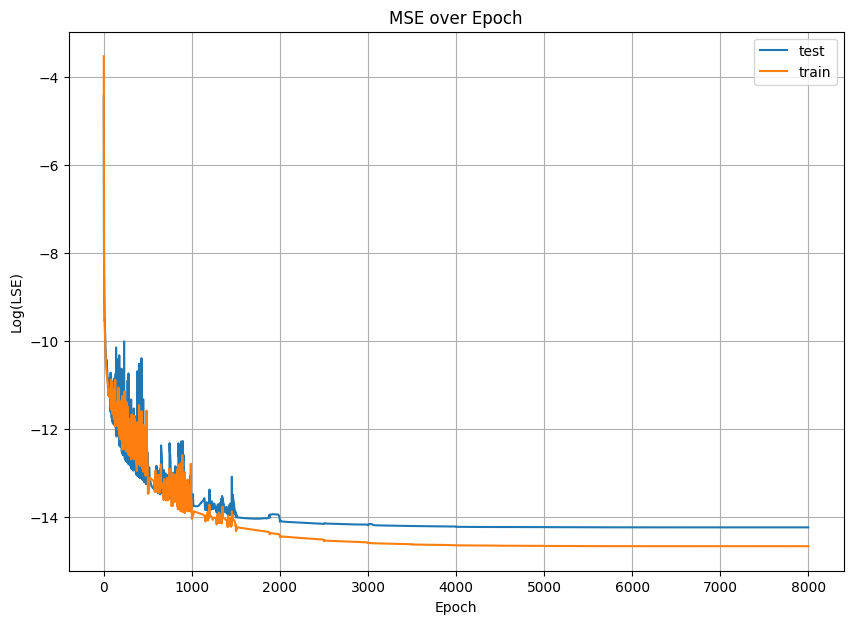

In [20]:
# Plotting log(MSE) as a function of epochs
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(LSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

In [29]:
# Loading model
device = 'cuda'
loaded_Heston_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/Heston_ANN.pt"
loaded_Heston_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_ANN.eval()

RuntimeError: Error(s) in loading state_dict for Heston_ANN:
	Unexpected key(s) in state_dict: "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias", "fc3.weight", "fc3.bias", "fc4.weight", "fc4.bias", "fc5.weight", "fc5.bias". 

In [27]:
state_dict = torch.load("Heston_ANN_DE.pt")
print("Keys in saved state_dict:", state_dict.keys())

# Compare with model's state_dict
dummy_model = Heston_ANN()
print("Keys in current model's state_dict:", dummy_model.state_dict().keys())


Keys in saved state_dict: odict_keys(['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias', 'fc4.weight', 'fc4.bias', 'fc5.weight', 'fc5.bias'])
Keys in current model's state_dict: odict_keys([])


In [26]:
state_dict = torch.load("Heston_ANN_DE.pt")
# Remove `module.` prefix if it exists
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("module.", "")  # Remove `module.` prefix
    new_state_dict[name] = v

model.load_state_dict(new_state_dict)


RuntimeError: Error(s) in loading state_dict for Heston_ANN:
	Unexpected key(s) in state_dict: "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias", "fc3.weight", "fc3.bias", "fc4.weight", "fc4.bias", "fc5.weight", "fc5.bias". 

In [25]:

# Recreate the model architecture
model = Heston_ANN()  # Make sure the architecture matches the saved model
model.load_state_dict(torch.load("Heston_ANN_DE.pt"))  # Load the saved weights
model.eval()  # Set the model to evaluation mode

# Example usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Test the loaded model with some input
example_input = torch.randn(1, input_size).to(device)  # Replace 'input_size' with your model's input size
output = model(example_input)

print("Output:", output)


RuntimeError: Error(s) in loading state_dict for Heston_ANN:
	Unexpected key(s) in state_dict: "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias", "fc3.weight", "fc3.bias", "fc4.weight", "fc4.bias", "fc5.weight", "fc5.bias". 

In [23]:
# Loading model
device = torch.device("cuda")
loaded_Heston_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/Heston_ANN_DE.pt"
loaded_Heston_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_ANN.eval()

# data loader 
loader = torch.utils.data.DataLoader(hs_dataset, 4048)
# Computing prices
prices = []
with torch.no_grad():
  for data in loader:
    data, _ = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    prices.append((output).data.cpu().numpy())
  prices = np.concatenate(prices)

RuntimeError: Error(s) in loading state_dict for Heston_ANN:
	Unexpected key(s) in state_dict: "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias", "fc3.weight", "fc3.bias", "fc4.weight", "fc4.bias", "fc5.weight", "fc5.bias". 

In [22]:
import torch
import numpy as np
from scipy import optimize
from torch.utils.data import DataLoader

# Define device for computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the Heston-ANN model
class Heston_ANN(torch.nn.Module):
    # Define your model architecture here if not already defined
    pass

loaded_Heston_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/Heston_ANN_DE.pt"
loaded_Heston_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_ANN.eval()

# Function to calculate implied volatility using Brent's method
def calc_implied_vol(dataset):
    """
    Computes implied volatilities using the Brent method.
    :param dataset: numpy array containing [S/K, T, r, OptionPrice].
    :return: A single implied volatility value.
    """
    money, T, r, market_price = dataset

    def bs_price(sigma):
        """Black-Scholes option price difference function."""
        d1 = (np.log(money) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        theoretical_price = money * norm.cdf(d1) - np.exp(-r * T) * norm.cdf(d2)
        return theoretical_price - market_price

    # Solve for implied volatility
    try:
        return optimize.brentq(bs_price, 1e-5, 5, maxiter=100)
    except ValueError:
        return np.nan  # Return NaN if Brent fails to converge

# Data generation or loading
hs_dataset = Heston_LHS_data_generator(10**5, l_bounds=l_bounds, u_bounds=u_bounds)
hs_data_loader = DataLoader(hs_dataset, batch_size=4048)

# Step 1: Compute prices using Heston-ANN
predicted_prices = []
with torch.no_grad():
    for data in hs_data_loader:
        inputs = data[:, :-1].to(device)  # Exclude the last column if it's labels
        outputs = loaded_Heston_ANN(inputs)
        predicted_prices.append(outputs.cpu().numpy())
predicted_prices = np.concatenate(predicted_prices)

# Step 2: Prepare the dataset for Brent's method
# Combine predicted prices with necessary inputs for implied volatility calculation
# Assuming hs_dataset.data contains [S/K, T, r, actual_price]:
hs_dataset_data = hs_dataset.data[:, np.array([0, 1, 2])]  # Extract relevant columns
hs_dataset_data = np.hstack((hs_dataset_data, predicted_prices.reshape(-1, 1)))

# Step 3: Calculate implied volatilities
implied_volatilities = np.apply_along_axis(calc_implied_vol, 1, hs_dataset_data)

# Step 4: Evaluate results
# Assuming you have ground-truth implied volatilities for comparison
ground_truth_vol = hs_dataset.data[:, 3]  # Replace with actual column for ground truth
mse = ((ground_truth_vol - implied_volatilities) ** 2).mean()
print(f"MSE: {mse:.6e}")


RuntimeError: Error(s) in loading state_dict for Heston_ANN:
	Unexpected key(s) in state_dict: "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias", "fc3.weight", "fc3.bias", "fc4.weight", "fc4.bias", "fc5.weight", "fc5.bias". 

In [ ]:
# Loading model
device = torch.device("cuda")
loaded_Heston_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/Heston_ANN_DE.pt"
loaded_Heston_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_ANN.eval()

# data loader 
loader = torch.utils.data.DataLoader(hs_dataset, 4048)
# Computing prices
prices = []
with torch.no_grad():
  for data in loader:
    data, _ = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    prices.append((output).data.cpu().numpy())
  prices = np.concatenate(prices)

# Loading model 
#device = torch.device("cuda")
#loaded_IV_ANN = IV_ANN().to(device)
#PATH = "ANN_weights/IV_SCALED_ANN.pt"
#loaded_IV_ANN.load_state_dict(torch.load(PATH))
#loaded_IV_ANN.eval()


# Plugging in the Heston-ANN prices
hs_dataset2 = hs_dataset.data[:,np.array([0,1,2,8])]
hs_dataset2.data[:,3] = torch.FloatTensor(prices)
loader2 = torch.utils.data.DataLoader(hs_dataset2, 4048)

# Computing IVs
implied_vol = []
indecies_list = []
with torch.no_grad():
  for idx, data in enumerate(loader2):
    data = data.to(device)
    # LOG Transformation
    data[:,3] = data[:,3] - torch.maximum(data[:,0]-torch.exp(-data[:,1]*data[:,2]),torch.zeros(data[:,0].shape).to(device))
    data[:,3] = torch.log(data[:,3])
    output = loaded_IV_ANN(data)
    implied_vol.append((output).data.cpu().numpy())
  implied_vol_pipe2 = np.concatenate(implied_vol)
  # indecies_list = np.concatenate(indecies_list).flatten()


In [41]:
# Heston model characteristic function
def charfun_heston(params, u, t):
    lambda_ = params[0]
    v_bar = params[1]
    eta = params[2]
    v0 = params[3]
    rho = params[4]

    beta = lambda_ - rho * eta * 1j * u
    alpha = -0.5 * u**2 - 0.5 * 1j * u
    zeta = 0.5 * eta**2

    d = np.sqrt(beta**2 - 4 * alpha * zeta)
    
    rm = (beta - d) / eta**2
    rp = (beta + d) / eta**2
    
    g = rm / rp
    C = rm * t - 2 / eta**2 * np.log((1 - g * np.exp(-d * t)) / (1 - g))
    D = rm * (1 - np.exp(-d * t)) / (1 - g * np.exp(-d * t))
    
    phi = np.exp(v_bar * lambda_ * C + v0 * D)
    
    return phi

In [42]:
# SINC operation function
def sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP):
    K = np.array(K) if isinstance(K, (list, np.ndarray)) else np.array([K])
    N = 2 ** pow
    
    # Construct truncation range
    Xl = -Xc + Xm
    Xh = Xc + Xm
    wid = Xh - Xl
    
    # Fourier modes for CoN put
    n = np.arange(1, N // 2, 2)
    wn = n / wid
    Il = 2 / n
    
    # Compute characteristic function values
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)

    # Zero-fill even frequencies
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il
    q2l = np.zeros(N // 2, dtype=complex)
    q2l[1::2] = f2l * Il
    
    Iu = -np.flip(Il)
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))
    
    # Zero-fill negative frequencies
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu
    q2u = np.zeros(N // 2, dtype=complex)
    q2u[::2] = f2u * Iu
    
    # Arrange for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])
    
    d1 = np.fft.fft(q1) + 0.5
    d2 = np.fft.fft(q2) + 0.5
    
    # Digital options computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]
    
    dd1 = np.concatenate([d12, d11])
    dd2 = np.concatenate([d22, d21])
    
    m = np.arange(-N // 2, N // 2)
    km = m * wid / N + (IR - DY) * t + Xm
    Km = S * np.exp(km)
    
    # Price options
    conP = np.exp(-IR * t) * np.real(Km * dd1)
    aonP = np.exp(-DY * t) * np.real(S * dd2)
    
    # Interpolation
    conP = np.interp(K, Km, conP)
    aonP = np.interp(K, Km, aonP)

    put = conP - aonP
    call = put + S * np.exp(-DY * t) - K * np.exp(-IR * t)

    # Clamp negative prices
    return call if CP == 1 else put

In [65]:
# cheking the function
N = 500
L= 12
r= .1
tau= 1.4
rho = -0.95
kappa= 1.4
vbar = .1
gamma = .1
v0 = 0.5
K = 100
S0 = 100
# Feller's condition
print(2*kappa*vbar>gamma**2)
call_option_Heston_moy(N = 1500, L= 12, r= r, tau= tau, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, moyeness = 1)

True


array([[0.29792611]])

In [66]:
def sinc_fast_ft_moy(t, IR, DY, params, Xc, Xm, pow):
    """
    SINC Fourier Transform for options pricing in terms of moneyness (S/K).
    
    Parameters:
    t : float
        Time to maturity.
    IR : float
        Risk-free interest rate.
    DY : float
        Dividend yield.
    params : list
        Heston model parameters [kappa, theta, sigma, rho, v0].
    Xc : float
        Center of truncation range.
    Xm : float
        Log-moneyness S/K.
    pow : int
        Power for determining number of points N (2^pow).
        
    Returns:
    ndarray
        Call or put option prices in moneyness space.
    """
    import numpy as np
    
    # Number of Fourier modes
    N = 2 ** pow

    # Construct truncation range
    Xl = -Xc + Xm  # Lower bound of truncation range
    Xh = Xc + Xm   # Upper bound of truncation range
    wid = Xh - Xl  # Width of truncation range

    # Fourier modes (frequencies) for SINC
    n = np.arange(1, N // 2, 2)  # Odd indices only
    wn = n / wid                 # Frequency spacing
    Il = 2 / n                   # Integral scaling factor

    # Compute characteristic function values for SINC
    f1l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn, t)
    f2l = np.exp(-1j * 2 * np.pi * wn * Xm) * charfun_heston(params, 2 * np.pi * wn - 1j, t)

    # Zero-fill even frequencies for FFT input
    q1l = np.zeros(N // 2, dtype=complex)
    q1l[1::2] = f1l * Il  # Assign odd indices
    q2l = np.zeros(N // 2, dtype=complex)
    q2l[1::2] = f2l * Il

    # Negative frequencies (mirrored and conjugate of positive ones)
    Iu = -np.flip(Il)  # Mirror the integral scaling factors
    f1u = np.flip(np.conj(f1l))
    f2u = np.flip(np.conj(f2l))

    # Zero-fill negative frequencies for FFT input
    q1u = np.zeros(N // 2, dtype=complex)
    q1u[::2] = f1u * Iu  # Assign even indices
    q2u = np.zeros(N // 2, dtype=complex)
    q2u[::2] = f2u * Iu

    # Prepare for FFT algorithm
    q1 = 1j / (2 * np.pi) * np.concatenate([q1l, [0], q1u[:-1]])
    q2 = 1j / (2 * np.pi) * np.concatenate([q2l, [0], q2u[:-1]])

    # Perform FFT
    d1 = np.fft.fft(q1) + 0.5  # Add 0.5 for proper normalization
    d2 = np.fft.fft(q2) + 0.5

    # Rearrange FFT outputs for digital option computation
    d11 = d1[:N // 2]
    d12 = d1[N // 2:]
    d21 = d2[:N // 2]
    d22 = d2[N // 2:]

    dd1 = np.concatenate([d12, d11])  # Combine rearranged values
    dd2 = np.concatenate([d22, d21])

    # Calculate moneyness vector
    m = np.arange(-N // 2, N // 2)  # Fourier indices
    km = m * wid / N + (IR - DY) * t + Xm  # Log-moneyness adjusted for discount factors

    # Price options in moneyness
    conP = np.exp(-IR * t) * np.real(np.exp(km) * dd1)  # Continuous payout option
    aonP = np.exp(-DY * t) * np.real(dd2)  # American option adjustment

    # Compute the final call or put option prices
    put = conP - aonP
    call = put + np.exp(-DY * t) - np.exp(-IR * t)

    return call, put


In [68]:
# cheking the function
CP = 1  # for Call options
S = 100
t = 1.4
K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
IR = 0.05  # Interest rate
DY = 0.02  # Dividend yield
params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
# Select Xc based on time to maturity
if t == 1.00:
    Xc = 12.1802  # Increased truncation range
Xm = 0
    
#pow = 20  # Increased FFT precision
pow = 21  # Increase precision
# Feller's condition
#print(2*kappa*vbar>gamma**2)
sinc_fast_ft_moy(t, IR, DY, params, Xc, Xm, pow)

(array([-5.83570219e-01, -5.83535430e-01, -5.83500638e-01, ...,
         1.08343936e+05,  1.08338416e+05,  1.08332896e+05]),
 array([-6.12539468e-01, -6.12504679e-01, -6.12469887e-01, ...,
         1.08343907e+05,  1.08338387e+05,  1.08332867e+05]))

In [69]:
import numpy as np

# Define helper functions (place your COS and SINC-related functions here)
# These are placeholders for your actual implementations.
# Ensure the `call_option_Heston` and `call_option_Heston_moy` functions are included.
# Ensure the `sinc_fast_ft` and `sinc_fast_ft_moy` functions are included.

# Define Heston characteristic function (replace with actual implementation)
def charfun_heston(params, u, tau):
    kappa, theta, sigma, rho, v0 = params
    i = complex(0.0, 1.0)
    x0 = np.log(1)  # Assume initial moneyness is 1
    d = np.sqrt((rho * sigma * i * u - kappa) ** 2 + (sigma ** 2) * (i * u + u ** 2))
    g = (kappa - rho * sigma * i * u - d) / (kappa - rho * sigma * i * u + d)
    C = (1 - np.exp(-d * tau)) / (sigma ** 2 * (1 - g * np.exp(-d * tau))) * (
        kappa * theta * (d * tau - 2 * np.log((1 - g * np.exp(-d * tau)) / (1 - g)))
    )
    D = (1 - np.exp(-d * tau)) / (sigma ** 2 * (1 - g * np.exp(-d * tau))) * (d * (1 - np.exp(-d * tau)))
    return np.exp(C + D * v0 + i * u * x0)

# Define parameters
params = [1.4, 0.1, 0.1, -0.95, 0.5]  # Heston parameters: kappa, theta, sigma, rho, v0
r = 0.1  # Risk-free rate
tau = 1.4  # Time to maturity
K = 100  # Strike price
S0 = 100  # Initial price
L = 12  # Truncation length for COS method
N = 500  # Number of terms in the series expansion
moyeness = S0 / K  # S/K for moneyness
pow = 10  # Power for SINC method (2^pow points)
Xc = 10  # Truncation range for SINC
Xm = 0  # Log-moneyness (assume S = K, Xm = 0)

# Calculate option prices using COS method
cos_price = call_option_Heston(N, L, r, tau, params[0], params[2], params[1], params[4], params[3], K, S0)
cos_price_moy = call_option_Heston_moy(N, L, r, tau, params[0], params[2], params[1], params[4], params[3], moyeness)

# Calculate option prices using SINC method
sinc_call, sinc_put = sinc_fast_ft_moy(tau, r, 0, params, Xc, Xm, pow)  # Dividend yield set to 0 for simplicity

# Compare results
tolerance = 1e-6
cos_vs_moy = np.abs(cos_price - cos_price_moy) < tolerance
sinc_vs_cos = np.abs(cos_price - sinc_call) < tolerance

# Print results
print("COS Price (Standard):", cos_price.flatten())
print("COS Price (Moyeness):", cos_price_moy.flatten())
print("SINC Price (Call):", sinc_call.flatten())

print("\nComparison Results:")
print("COS Standard vs. COS Moyeness:", "Match" if cos_vs_moy.all() else "Mismatch")
print("COS vs. SINC (Call Prices):", "Match" if sinc_vs_cos.all() else "Mismatch")


COS Price (Standard): [29.79261082]
COS Price (Moyeness): [0.29792611]
SINC Price (Call): [ 1.69388399e+183 -1.70115849e+183  1.70812133e+183 ... -2.18286919e+186
  2.50310989e+186 -2.83671194e+186]

Comparison Results:
COS Standard vs. COS Moyeness: Mismatch
COS vs. SINC (Call Prices): Mismatch


In [ ]:
# New COS_v2 implementation wrapper
def COS_v2(S, t, K, IR, DY, params, N, L):
    kappa, vbar, gamma, v0, rho = params
    r = IR
    tau = t
    S_adjusted = S * np.exp(-DY * tau)  # Adjust spot price for dividend yield
    call_prices = []
    for strike in K:
        price = call_option_Heston(N, L, r, tau, kappa, gamma, vbar, v0, rho, strike, S_adjusted)
        call_prices.append(price[0, 0])
    return np.array(call_prices)

# Main function with both COS_method and COS_v2
def main():
    CP = 1  # for Call options
    S = 1
    t = 1.00
    K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
    IR = 0.05  # Interest rate
    DY = 0.02  # Dividend yield
    params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
    Xc = 12.1802 if t == 1.00 else 8.0
    Xm = 0
    N = 256  # Number of terms in COS expansion
    L = 12  # Truncation range for COS_v2

    # Prices using the original COS_method
    cos_prices = COS_method(S, t, K, IR, DY, "heston", params, Xc, Xm, N, CP, 1)
    
    # Prices using COS_v2
    cos_v2_prices = COS_v2(S, t, K, IR, DY, params, 1500, L)

    # Black-Scholes prices
    sigma_bs = np.sqrt(params[1])  # Approximate Black-Scholes volatility using v_bar
    bs_prices = [black_scholes(S, k, t, IR, sigma_bs, "call" if CP == 1 else "put") for k in K]
    
    # Plot results
    
    #plt.plot(K, cos_v2_prices, label="Heston Model (COS_ANN)", linestyle='--', marker='s')
    plt.plot(K, cos_v2_prices, label="Heston Model (COS_ANN)", marker='s')
    plt.plot(K, cos_prices, label="Heston Model (COS)", linestyle='--', marker='o')
    plt.plot(K, bs_prices, label="Black-Scholes", marker='x')
    plt.xlabel("Strike Price (K)")
    plt.ylabel("Option Price")
    plt.title("Option Price Comparison: COS Method vs COS_ANN vs Black-Scholes")
    plt.legend()
    plt.show()

# Run the main function
main()


In [ ]:
CP = 1  # for Call options
S = 1
t = 1.00
K = S * np.arange(0.60, 1.41, 0.10)  # Strike prices
IR = 0.05  # Interest rate
DY = 0.02  # Dividend yield
params = [1.5768, 0.0398, 0.5751, 0.0175, -0.5711]  # Heston parameters
    
# Select Xc based on time to maturity
if t == 1.00:
    Xc = 12.1802  # Increased truncation range
Xm = 0
    
#pow = 20  # Increased FFT precision
pow = 21  # Increase precision

heston_prices = sinc_fast_ft(S, t, K, IR, DY, params, Xc, Xm, pow, CP)

# 4) Heston pricing network: Heston-ANN

### Generating Data

In [11]:
# Table 3 of Liu et al.
# moneyness m =
eps = 1e-2 # is used to generate open intervals
def Heston_LHS_data_generator(n = 10**6, l_bounds = [.6+eps, .05+eps, .0+eps, -0.9+eps, 0.4+eps, .01+eps, .01+eps, .05+eps], u_bounds = [1.4-eps, 3.0-eps, .05-eps, 0.0-eps, 3.0-eps, .5-eps, .8-eps, .5-eps]):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,9) containig the inputs samples and the value of the call.
  The inputs are: Moyeness (S/K), time to maturity (tau), Risk free rate (r), Correlation (rho), reversion speed (kappa), Long average variance (vbar), Vol of vol (gamma), Initial variance (v0).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.
  """
  sampler = qmc.LatinHypercube(d = 8) #, seed = 0
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  indecies = np.argwhere(2*sample[:,4]*sample[:,5] <= sample[:,6]**2)
  sample = np.delete(sample, indecies, 0)
  hs_prices = call_option_Heston_moy(N = 160, L= 12, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa = sample[:,4].reshape((-1,1)),\
                                     gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
                                     rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))
  # hs_prices = call_option_Heston_moy(N = 1500, L= 50, r= sample[:,2].reshape((-1,1)), tau= sample[:,1].reshape((-1,1)), kappa= sample[:,4].reshape((-1,1)),\
  #                                    gamma = sample[:,6].reshape((-1,1)), vbar = sample[:,5].reshape((-1,1)), v0 = sample[:,7].reshape((-1,1)),\
  #                                    rho = sample[:,3].reshape((-1,1)), moyeness = sample[:,0].reshape((-1,1))).reshape((-1,1))

  hs_dataset = np.concatenate((sample, hs_prices),axis=1)

  print("------ INPUT ------")
  print("S/K.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,0]), max(hs_dataset[:,0])))
  print("Tau.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,1]), max(hs_dataset[:,1])))
  print("r............ [{:.2f} {:.2f}]".format(min(hs_dataset[:,2]), max(hs_dataset[:,2])))
  print("Corr ........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,3]), max(hs_dataset[:,3])))
  print("Kappa........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,4]), max(hs_dataset[:,4])))
  print("V_bar........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,5]), max(hs_dataset[:,5])))
  print("Gamma........ [{:.2f} {:.2f}]".format(min(hs_dataset[:,6]), max(hs_dataset[:,6])))
  print("V_0 ......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,7]), max(hs_dataset[:,7])))
  print("------ OUTPUT ------")
  print("V/K.......... [{:.2f} {:.2f}]".format(min(hs_dataset[:,-1]), max(hs_dataset[:,-1])))
  # ind_max = np.argmax(hs_dataset[:,-1])
  # print(hs_dataset[ind_max,:])

  return torch.FloatTensor(hs_dataset)

hs_dataset = Heston_LHS_data_generator(10**4)

------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.06 2.99]
r............ [0.01 0.04]
Corr ........ [-0.89 -0.01]
Kappa........ [0.41 2.99]
V_bar........ [0.02 0.49]
Gamma........ [0.02 0.79]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.75]


### Defining class Heston-ANN

In [12]:
class Heston_ANN(BS_ANN):
  def __init__(self):
    """
    Initilize BS-Heston_ANN netwwork. Same architecture as the one used in tge article.
    Weight are initialized using Glorot_uniform also known as Xavier_uniform.
    Takes inputs of size 8.
    """
    super(Heston_ANN, self).__init__()
    self.fc1 = nn.Linear(8, 400)
    self.fc2 = nn.Linear(200, 200)
    self.fc3 = nn.Linear(200, 200)
    self.fc4 = nn.Linear(200, 200)
    self.fc5 = nn.Linear(200, 1)

    torch.nn.init.xavier_uniform_(self.fc1.weight)
    torch.nn.init.xavier_uniform_(self.fc2.weight)
    torch.nn.init.xavier_uniform_(self.fc3.weight)
    torch.nn.init.xavier_uniform_(self.fc4.weight)
    torch.nn.init.xavier_uniform_(self.fc5.weight)

### Training Heston-ANN

In [13]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 8*10**3,
         "lr": 1e-4,
         "gamma": .5,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Loading Train / Test Data
hs_dataset = Heston_LHS_data_generator(n = 10**5)
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0] - train_size])

train_loader = torch.utils.data.DataLoader(train_dataset, args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = Heston_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=500, gamma=args["gamma"]) # Deacreses the Learning rate by .5 every 500 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  unique_model_name = "Heston_ANN_DE.pt"  # Set a unique name for the model
  torch.save(model.state_dict(), unique_model_name)
  print(f"Model saved as {unique_model_name}")

    

------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.06 2.99]
r............ [0.01 0.04]
Corr ........ [-0.89 -0.01]
Kappa........ [0.41 2.99]
V_bar........ [0.02 0.49]
Gamma........ [0.02 0.79]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [-0.00 0.77]
cuda


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1024x400 and 200x200)

Training WIDE 1.3450140548908723e-07 VS in the article 8.04e-09


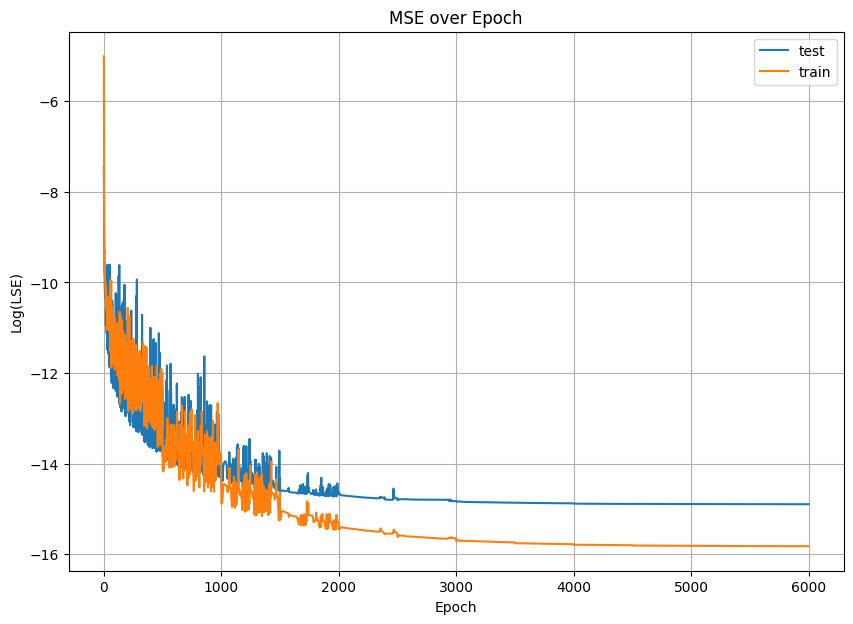

In [62]:
# Plotting log(MSE) as a function of epochs
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(LSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

In [7]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 8*10**3,
         "lr": 1e-4,
         "gamma": .5,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Loading Train / Test Data
hs_dataset = Heston_LHS_data_generator(n = 10**5)
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0] - train_size])

train_loader = torch.utils.data.DataLoader(train_dataset, args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = Heston_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=500, gamma=args["gamma"]) # Deacreses the Learning rate by .5 every 500 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  unique_model_name = "Heston_ANN_DE.pt"  # Set a unique name for the model
  torch.save(model.state_dict(), unique_model_name)
  print(f"Model saved as {unique_model_name}")

    

------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.06 2.99]
r............ [0.01 0.04]
Corr ........ [-0.89 -0.01]
Kappa........ [0.41 2.99]
V_bar........ [0.02 0.49]
Gamma........ [0.02 0.79]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.77]
cuda


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1024x400 and 200x200)

Training WIDE 1.4174312493500576e-07 VS in the article 8.04e-09


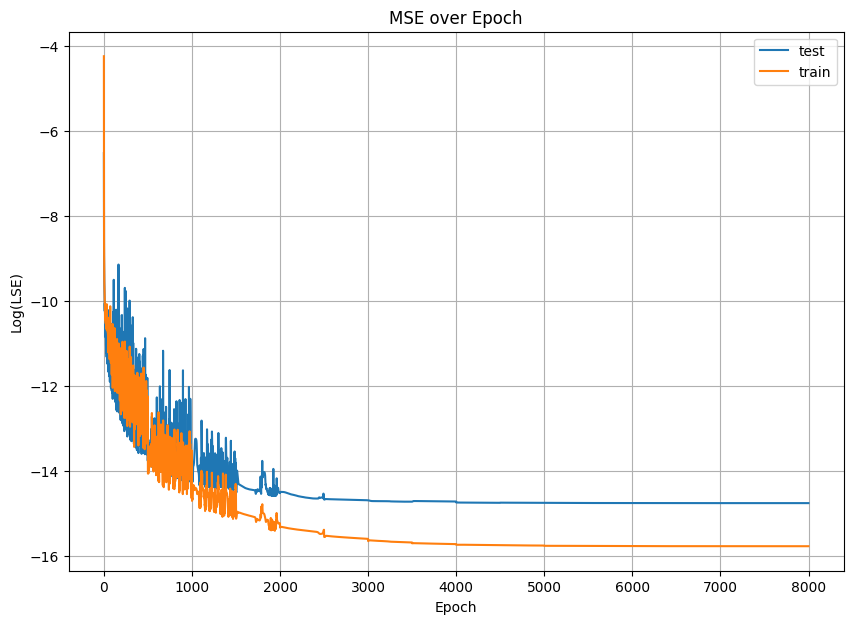

In [64]:
# Plotting log(MSE) as a function of epochs
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(LSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

In [ ]:
import numpy as np
from scipy.optimize import differential_evolution

# Heston model parameters
def heston_model(params, *args):
    """
    Heston model pricing function.
    Args:
        params: [kappa, theta, sigma, rho, v0]
        args: Additional arguments (e.g., strike price, interest rate, etc.)
    Returns:
        Option price difference (for optimization).
    """
    kappa, theta, sigma, rho, v0 = params
    market_price, strike, T, r, S0 = args  # Unpack additional arguments
    
    # Forward pass (your existing implementation)
    # Replace this with your actual Heston forward pass code
    model_price = your_forward_pass(S0, strike, T, r, kappa, theta, sigma, rho, v0)
    
    # Objective: minimize the difference between model and market prices
    return abs(model_price - market_price)

# Example inputs for the Heston model and DE optimization
market_price = 10.0  # Example market option price
strike = 100         # Strike price
T = 1.0              # Maturity (in years)
r = 0.05             # Risk-free rate
S0 = 100             # Initial stock price

# Bounds for the Heston parameters: [kappa, theta, sigma, rho, v0]
bounds = [(0.01, 5.0),   # kappa
          (0.01, 1.0),   # theta
          (0.01, 1.0),   # sigma
          (-1.0, 1.0),   # rho
          (0.01, 1.0)]   # v0

# Run Differential Evolution to calibrate Heston parameters
result = differential_evolution(
    heston_model,
    bounds,
    args=(market_price, strike, T, r, S0),
    strategy='best1bin',
    maxiter=1000,
    tol=1e-6
)

# Print the optimized Heston parameters
print("Optimized Heston Parameters:", result.x)


In [72]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import numpy as np
from scipy.optimize import differential_evolution
from torch.utils.data import DataLoader, random_split


torch.manual_seed(args["seed"])

# Calibrate Heston parameters using Differential Evolution
def calibrate_heston(market_price, strike, T, r, S0):
    bounds = [(0.01, 5.0), (0.01, 1.0), (0.01, 1.0), (-1.0, 1.0), (0.01, 1.0)]
    result = differential_evolution(
        heston_model,
        bounds,
        args=(market_price, strike, T, r, S0),
        strategy="best1bin",
        maxiter=1000,
        tol=1e-6,
    )
    return result.x


# Heston dataset generator (replace this with the actual implementation)
#def Heston_LHS_data_generator(n):
#    # Generate synthetic Heston data using Latin Hypercube Sampling
#    return torch.rand((n, 5))  # Example 5 columns: S0, strike, T, r, price

# Loading Train/Test Data
hs_dataset = Heston_LHS_data_generator(n=10**5)
train_size, test_size = int(hs_dataset.shape[0] * 0.9), int(hs_dataset.shape[0] * 0.1)
train_dataset, test_dataset = random_split(hs_dataset, [train_size, hs_dataset.shape[0] - train_size])

train_loader = DataLoader(train_dataset, args["batch_size"])
test_loader = DataLoader(test_dataset, args["test_batch_size"])

# Model training
model = Heston_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"])
scheduler = StepLR(optimizer, step_size=500, gamma=args["gamma"])

train_losses = []
test_losses = []

for epoch in range(1, args["epochs"] + 1):
    train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
    test_loss = model.test_model(device, test_loader)
    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}")
    print(f"Current Learning rate: {scheduler.get_last_lr()[0]}")
    scheduler.step()
    train_losses.append(train_loss)
    test_losses.append(test_loss)

if args["save_model"]:
    torch.save(model.state_dict(), "Heston_ANN.pt")

# Example of Heston calibration
market_price = 10.0  # Example market price
strike = 100
T = 1.0
r = 0.05
S0 = 100

optimized_params = calibrate_heston(market_price, strike, T, r, S0)
print("Optimized Heston Parameters:", optimized_params)


ValueError: too many values to unpack (expected 2)

In [70]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import numpy as np
from scipy.optimize import differential_evolution
from torch.utils.data import DataLoader, random_split

# Training parameters
args = {
    "batch_size": 1024,
    "test_batch_size": 4048,
    "epochs": 8 * 10**3,
    "lr": 1e-4,
    "gamma": 0.5,
    "no_cuda": False,
    "run_dry": False,
    "seed": 0,
    "log_interval": 100,
    "dry_run": False,
    "save_model": True,
}

use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
torch.manual_seed(args["seed"])


# Define Heston model pricing
def heston_forward(S0, strike, T, r, kappa, theta, sigma, rho, v0):
    # Replace this with your Heston model implementation
    # Dummy forward pricing function (placeholder for the actual implementation)
    return np.random.uniform(8, 12)  # Replace with true pricing function


def heston_model(params, *args):
    """Heston model calibration objective function."""
    kappa, theta, sigma, rho, v0 = params
    market_price, strike, T, r, S0 = args
    model_price = heston_forward(S0, strike, T, r, kappa, theta, sigma, rho, v0)
    return abs(model_price - market_price)


# Calibrate Heston parameters using Differential Evolution
def calibrate_heston(market_price, strike, T, r, S0):
    bounds = [(0.01, 5.0), (0.01, 1.0), (0.01, 1.0), (-1.0, 1.0), (0.01, 1.0)]
    result = differential_evolution(
        heston_model,
        bounds,
        args=(market_price, strike, T, r, S0),
        strategy="best1bin",
        maxiter=1000,
        tol=1e-6,
    )
    return result.x


# Heston dataset generator (replace this with the actual implementation)
def Heston_LHS_data_generator(n):
    # Generate synthetic Heston data using Latin Hypercube Sampling
    return torch.rand((n, 5))  # Example 5 columns: S0, strike, T, r, price


# Define Heston ANN (replace with your model architecture)
class Heston_ANN(torch.nn.Module):
    def __init__(self):
        super(Heston_ANN, self).__init__()
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(5, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.fc(x)

    def train_model(self, args, device, train_loader, optimizer, epoch):
        self.train()
        total_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = self(data)
            loss = torch.nn.functional.mse_loss(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    def test_model(self, device, test_loader):
        self.eval()
        test_loss = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = self(data)
                test_loss += torch.nn.functional.mse_loss(output, target).item()
        return test_loss / len(test_loader)


# Loading Train/Test Data
hs_dataset = Heston_LHS_data_generator(n=10**5)
train_size, test_size = int(hs_dataset.shape[0] * 0.9), int(hs_dataset.shape[0] * 0.1)
train_dataset, test_dataset = random_split(hs_dataset, [train_size, hs_dataset.shape[0] - train_size])

train_loader = DataLoader(train_dataset, args["batch_size"])
test_loader = DataLoader(test_dataset, args["test_batch_size"])

# Model training
model = Heston_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"])
scheduler = StepLR(optimizer, step_size=500, gamma=args["gamma"])

train_losses = []
test_losses = []

for epoch in range(1, args["epochs"] + 1):
    train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
    test_loss = model.test_model(device, test_loader)
    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}")
    print(f"Current Learning rate: {scheduler.get_last_lr()[0]}")
    scheduler.step()
    train_losses.append(train_loss)
    test_losses.append(test_loss)

if args["save_model"]:
    torch.save(model.state_dict(), "Heston_ANN.pt")

# Example of Heston calibration
market_price = 10.0  # Example market price
strike = 100
T = 1.0
r = 0.05
S0 = 100

optimized_params = calibrate_heston(market_price, strike, T, r, S0)
print("Optimized Heston Parameters:", optimized_params)


ValueError: too many values to unpack (expected 2)

In [25]:
# Loading model
device = 'cuda'
loaded_Heston_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/Heston_ANN.pt"
loaded_Heston_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_ANN.eval()


Heston_ANN(
  (fc1): Linear(in_features=8, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

In [26]:
# Loading Train / Test Data
hs_dataset = Heston_LHS_data_generator(n = 10**5)
train_size, test_size = int(hs_dataset.shape[0]*0.9), int(hs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(hs_dataset, [train_size, hs_dataset.shape[0]-train_size])
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}
train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])

(93278, 8)
True
------ INPUT ------
S/K.......... [0.61 1.39]
Tau.......... [0.11 1.39]
r............ [0.01 0.09]
Corr ........ [-0.94 -0.01]
Kappa........ [0.41 1.99]
V_bar........ [0.01 0.49]
Gamma........ [0.01 0.49]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.63]


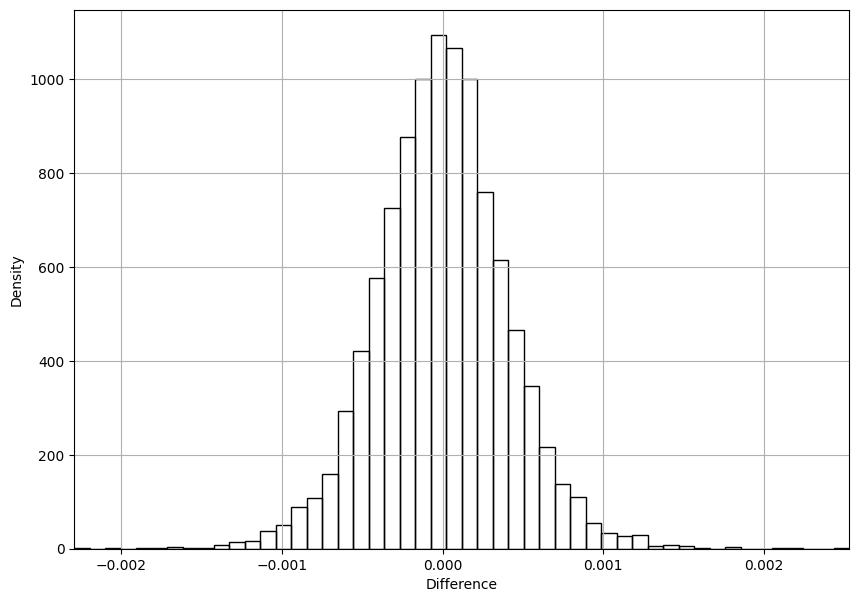

MAX  0.0025307536
MIN  -0.0022904128


In [27]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    errors.append((target - output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors, 50, fill=False, density=True)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
#plt.xlim([-0.003, 0.003])
plt.xlim([errors.min(), errors.max()])
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [28]:
# printing train and test erros MSE, MAE, MAPE, R2.
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs, targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs, targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs, targets)) )
print("R2 {:e}".format(r2_score(outputs, targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs, targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs, targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs, targets)) )
print("R2 {:e}".format(r2_score(outputs, targets)) )

-----------Train scores----------------
MSE 1.620412e-07
MAE 3.072428e-04
MAPE 1.827646e-02
R2 9.999926e-01
-----------Test scores----------------
MSE 1.642187e-07
MAE 3.112399e-04
MAPE 1.504550e-02
R2 9.999926e-01


In [29]:
np.sqrt(1.670718e-07)
print("MSE {:e}".format(np.sqrt(1.670718e-07)) )

MSE 4.087442e-04


# 5) BRENT

In [30]:
from scipy import optimize

def calcimpliedvol(dataset):
    """
    Computes the implied volatilities using the brent method.
    dataset: numpy array containing moneyness, time to maturity, risk free interest rate and V/K.
    Returns a vector of implied volatilities.
    """
    money = np.array(dataset[0])
    T = np.array(dataset[1])
    r = np.array(dataset[2])
    marketoptionPrice = np.array(dataset[3])
    def bs_price(sigma):
      d1 = ( np.log(money) + (r + 0.5 * sigma ** 2) * (T) ) / (sigma * np.sqrt(T))
      d2 = d1 - sigma*np.sqrt(T)
      value_moyeness = money * norm.cdf(d1) - np.exp(-r * (T)) * norm.cdf(d2) 
      fx = value_moyeness - marketoptionPrice
      return fx
    return optimize.brentq(bs_price, -1, 1, maxiter=100)

bs_dataset = bs_LHS_data_generator(n=10**4).data
ground_truth_vol = bs_dataset[:,3]
bs_dataset = bs_dataset[:,np.array([0,1,2,4])]

vol_imp = np.apply_along_axis(calcimpliedvol, 1, bs_dataset)
print("MSE ", ((ground_truth_vol - vol_imp)**2).mean().item())
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )

------ INPUT ------
S/K.......... [0.40 1.60]
Tau.......... [0.20 1.10]
r............ [0.02 0.10]
Sigma........ [0.01 1.00]
------ OUTPUT ------
V/K.......... [0.00 0.87]
MSE  0.00016247822395714246
MSE 1.642187e-07


# 6) Pipeline 1: COS + BRENT

In [31]:
eps = 1e-2 # is used to generate open intervals
# (S/K), (tau), (r), (rho), (kappa), (vbar), (gamma), (v0).
# CASE 1 in table 11
l_bounds = [.75+eps, .4+eps, .0+eps, -0.95+eps, .4+eps, .0+eps, .0+eps, .05+eps]
u_bounds = [1.25-eps, 1.0-eps, .1-eps, 0.0-eps, 2.0-eps, .5-eps, .5-eps, .5-eps]
hs_dataset = Heston_LHS_data_generator(10**5, l_bounds = l_bounds, u_bounds=u_bounds)
hs_dataset_data = hs_dataset.data
hs_dataset_data = hs_dataset_data[:,np.array([0,1,2,8])]
implied_vol_pipe1 = np.apply_along_axis(calcimpliedvol, 1, hs_dataset_data)

(93167, 8)
True
------ INPUT ------
S/K.......... [0.76 1.24]
Tau.......... [0.41 0.99]
r............ [0.01 0.09]
Corr ........ [-0.94 -0.01]
Kappa........ [0.41 1.99]
V_bar........ [0.01 0.49]
Gamma........ [0.01 0.49]
V_0 ......... [0.06 0.49]
------ OUTPUT ------
V/K.......... [0.00 0.46]


# 7) Pipeline 2: Heston-ANN + IV-ANN

In [32]:
# Loading model
device = torch.device("cuda")
loaded_Heston_ANN = Heston_ANN().to(device)
PATH = "ANN_weights/Heston_ANN.pt"
loaded_Heston_ANN.load_state_dict(torch.load(PATH))
loaded_Heston_ANN.eval()

# data loader 
loader = torch.utils.data.DataLoader(hs_dataset, 4048)
# Computing prices
prices = []
with torch.no_grad():
  for data in loader:
    data, _ = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_Heston_ANN(data)
    prices.append((output).data.cpu().numpy())
  prices = np.concatenate(prices)

# Loading model 
device = torch.device("cuda")
loaded_IV_ANN = IV_ANN().to(device)
PATH = "ANN_weights/IV_SCALED_ANN.pt"
loaded_IV_ANN.load_state_dict(torch.load(PATH))
loaded_IV_ANN.eval()


# Plugging in the Heston-ANN prices
hs_dataset2 = hs_dataset.data[:,np.array([0,1,2,8])]
hs_dataset2.data[:,3] = torch.FloatTensor(prices)
loader2 = torch.utils.data.DataLoader(hs_dataset2, 4048)

# Computing IVs
implied_vol = []
indecies_list = []
with torch.no_grad():
  for idx, data in enumerate(loader2):
    data = data.to(device)
    # LOG Transformation
    data[:,3] = data[:,3] - torch.maximum(data[:,0]-torch.exp(-data[:,1]*data[:,2]),torch.zeros(data[:,0].shape).to(device))
    data[:,3] = torch.log(data[:,3])
    output = loaded_IV_ANN(data)
    implied_vol.append((output).data.cpu().numpy())
  implied_vol_pipe2 = np.concatenate(implied_vol)
  # indecies_list = np.concatenate(indecies_list).flatten()


In [33]:
# Eliminating Nan values resulting from prices lower than 1e-7
indecies = np.argwhere(np.isnan(implied_vol_pipe2))
implied_vol_pipe1 = np.delete(implied_vol_pipe1, indecies,0)
implied_vol_pipe2 = np.delete(implied_vol_pipe2, indecies,0)

# 8) Pipeline 1 VS pipeline 2

In [34]:
# CASE 1
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
outputs = implied_vol_pipe2
targets = implied_vol_pipe1
#targets = vol_imp
print("-----------Vol scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("RMSE {:e}".format(np.sqrt(mean_squared_error(outputs,targets))) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Vol scores----------------
MSE 2.062010e-06
RMSE 1.435970e-03
MAE 1.113229e-03
MAPE 2.355020e-03
R2 9.997822e-01


In [35]:
# CASE 2
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
outputs = implied_vol_pipe2
targets = implied_vol_pipe1
print("-----------Vol scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("RMSE {:e}".format(np.sqrt(mean_squared_error(outputs,targets))) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Vol scores----------------
MSE 2.062010e-06
RMSE 1.435970e-03
MAE 1.113229e-03
MAPE 2.355020e-03
R2 9.997822e-01


# 9) Volatility surface (COS + IV-ANN)

### Initial volatility surface

In [36]:
# Generating the surface points
r= .02
tau= 0.5
rho = -0.05
kappa= 1.5
vbar = .1
gamma = .3
v0 = 0.1
moyeness = 0.74
moyeness = np.linspace(moyeness, 1.24,11)
tau = np.linspace(tau, 1, 6)

cos_prices = []
X = []
Y = []
for m in moyeness:
  for t in tau:
    X.append(m)
    Y.append(t)
    cos_prices.append(call_option_Heston_moy(N = 160, L= 12, r= r, tau= t, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, moyeness = m))

In [37]:
# Reshaping for torch tensor dataset
cos_prices = np.array(cos_prices).reshape((-1, 1))
X = np.array(X).reshape((-1, 1))
Y = np.array(Y).reshape((-1, 1))
r = np.array(r*np.ones(66)).reshape((-1, 1))

In [40]:
# Creating a torch dataset
data = np.concatenate((X, Y, r, cos_prices), axis = 1)
data = torch.FloatTensor(data)

AxisError: axis 1 is out of bounds for array of dimension 1

In [38]:
# Getting the implied volatility from the dataset
with torch.no_grad():
  data = data.to(device)
  data[:,3] = data[:,3] - torch.maximum(data[:,0]-torch.exp(-data[:,1]*data[:,2]),torch.zeros(data[:,0].shape).to(device))
  data[:,3] = torch.log(data[:,3])
  output = loaded_IV_ANN(data)
  bs_IV = (output).data.cpu().numpy()

X = X.flatten()
Y = Y.flatten()
Z = bs_IV

x = np.reshape(X, (-1, 6))
y = np.reshape(Y, (-1, 6))
z = np.reshape(Z, (-1, 6))

ValueError: cannot reshape array of size 63 into shape (6)

In [64]:
from mpl_toolkits import mplot3d
from matplotlib import cm

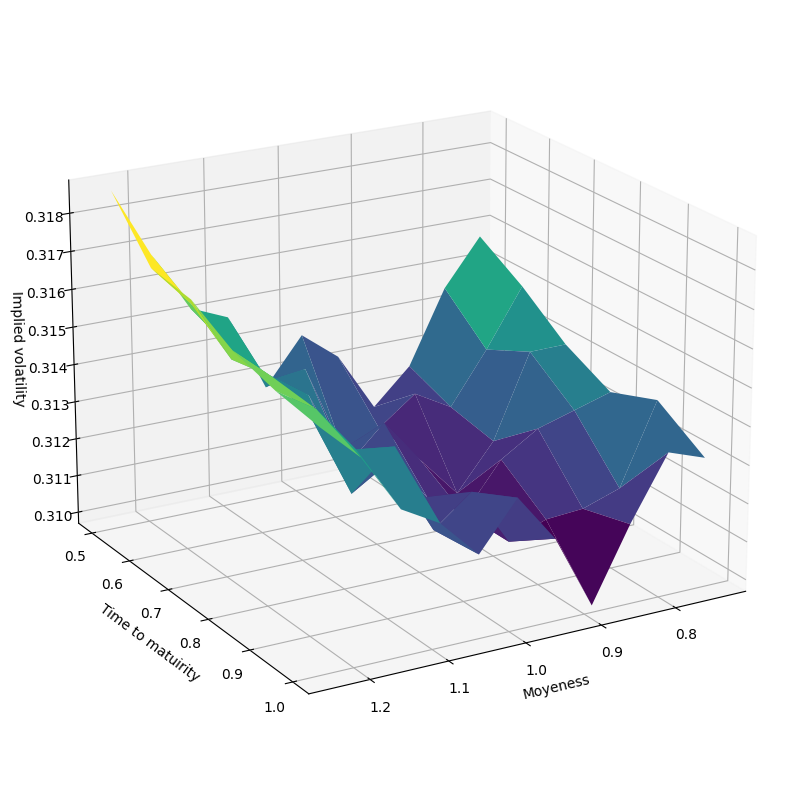

In [65]:
# Plotting the initial volatility surface
plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(elev=20, azim=60)
ax.plot_surface(x, y, z,cmap='viridis', edgecolor='none', antialiased=True)
ax.set_xlabel('Moyeness')
ax.set_ylabel('Time to matuirity')
ax.set_zlabel('Implied volatility')
plt.show()

### Smoothing the volatility surface

In [66]:
from scipy import interpolate

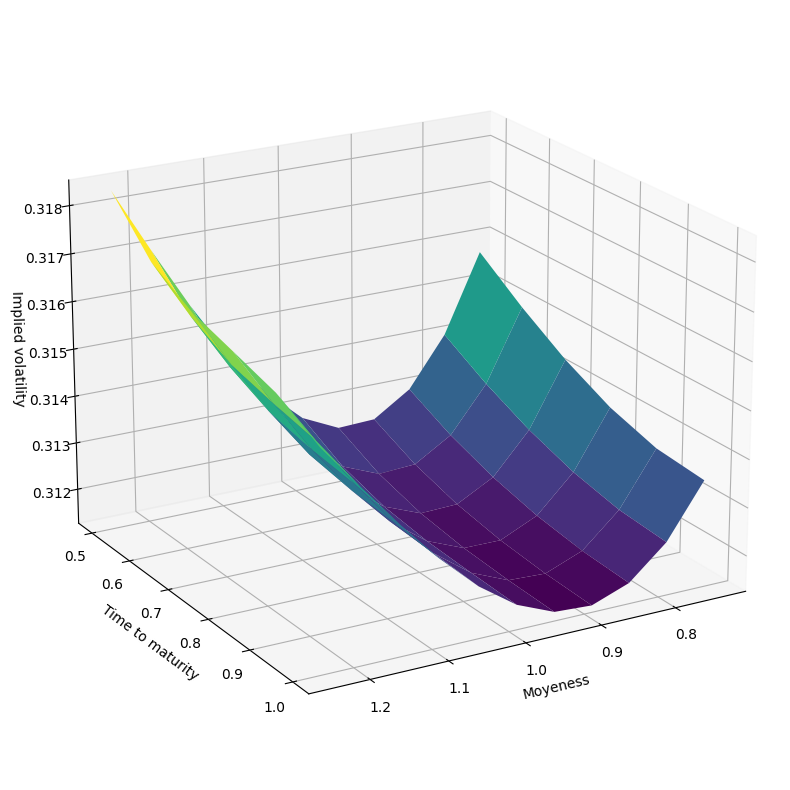

In [67]:
# Smoothing the volatility surface
xnew, ynew = x.copy(), y.copy()
tck = interpolate.bisplrep(x, y, z, s=1.0)
znew = interpolate.bisplev(xnew[:,0], ynew[0,:], tck)

plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
ax.view_init(elev=20, azim=60)
ax.plot_surface(xnew, ynew, znew,cmap='viridis', edgecolor='none', antialiased=True)
ax.set_xlabel('Moyeness')
ax.set_ylabel('Time to maturity')
ax.set_zlabel('Implied volatility')
plt.show()

### Implied volatility difference

In [68]:
# Generating the surface points
r= .02
tau= 0.5
rho = -0.05
kappa= 1.5
vbar = .1
gamma = .3
v0 = 0.1
moyeness = 0.74
n_moneyness = 11
n_tau = 6
moyeness = np.linspace(moyeness, 1.24,n_moneyness)
tau = np.linspace(tau, 1, n_tau)

cos_prices = []
X = []
Y = []
for m in moyeness:
  for t in tau:
    X.append(m)
    Y.append(t)
    cos_prices.append(call_option_Heston_moy(N = 160, L= 12, r= r, tau= t, kappa= kappa, gamma = gamma, vbar = vbar, v0 = v0, rho = rho, moyeness = m))

In [69]:
rho = np.array(rho*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
kappa = np.array(kappa*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
vbar = np.array(vbar*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
gamma = np.array(gamma*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
v0 = np.array(v0*np.ones(n_tau * n_moneyness)).reshape((-1, 1))
# Reshaping for torch tensor dataset
cos_prices = np.array(cos_prices).reshape((-1, 1))
X = np.array(X).reshape((-1, 1))
Y = np.array(Y).reshape((-1, 1))
r = np.array(r*np.ones(n_tau * n_moneyness)).reshape((-1, 1))

In [70]:
data_ann = np.concatenate((X, Y, r, rho, kappa, vbar, gamma, v0, cos_prices), axis = 1)
data_ann = torch.FloatTensor(data_ann)
# Creating a torch dataset
data = np.concatenate((X, Y, r, cos_prices), axis = 1)
data = torch.FloatTensor(data)

In [71]:
implied_vol_pipe1 = np.apply_along_axis(calcimpliedvol, 1, data)

In [72]:
# Getting the implied volatility from the dataset
with torch.no_grad():
  data = data.to(device)
  data[:,3] = data[:,3] - torch.maximum(data[:,0]-torch.exp(-data[:,1]*data[:,2]),torch.zeros(data[:,0].shape).to(device))
  data[:,3] = torch.log(data[:,3])
  output = loaded_IV_ANN(data)
  implied_vol_pipe2 = (output).data.cpu().numpy()



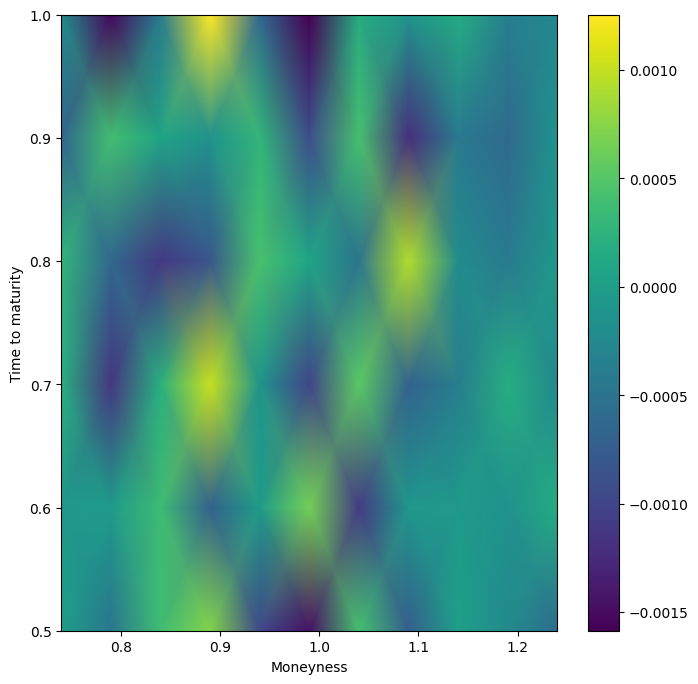

In [73]:
X = X.flatten()
Y = Y.flatten()
Z = (implied_vol_pipe1 - implied_vol_pipe2).flatten()

x = np.reshape(X, (-1, min(n_moneyness, n_tau)))
y = np.reshape(Y, (-1, min(n_moneyness, n_tau)))
z = np.reshape(Z, (-1, min(n_moneyness, n_tau)))

plt.figure(figsize=(8,8))
plt.pcolormesh(x, y, z, shading='gouraud')
plt.colorbar()
plt.xlabel("Moneyness")
plt.ylabel("Time to maturity")
plt.show()